# BIAS DISTRIBUTION ANALYSIS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pandas as pd

In [3]:
%cd ..

f:\robusto\vqa_analysis


In [4]:
df = pd.read_csv("./data/r2_cleaned.csv",keep_default_na=False)
df["REPETITION"] = df["REPETITION"].astype(np.uint8)
df["QUESTION_NUM"] = df["QUESTION_NUM"].astype(np.uint8)
#get video number Robusto2_XXX and convert to int8
def get_video_num(video_str):
    try:
        return int(video_str.split("_")[1])
    except (IndexError, ValueError):
        return np.nan
df["BLOCK"] = df["BLOCK"].astype(np.uint8)
df["VIDEO"] = df["VIDEO"].astype("category")
#df["AGENT"] = df["AGENT"].astype("category")

#check for non strings in the ANSWER column
non_string_answers = df[~df['ANSWER'].apply(lambda x: isinstance(x, str))]
print("Non-string answers:")
print(non_string_answers)

df.info()

Non-string answers:
Empty DataFrame
Columns: [AGENT, VIDEO, BLOCK, QUESTION_NUM, REPETITION, ANSWER]
Index: []
<class 'pandas.DataFrame'>
RangeIndex: 86800 entries, 0 to 86799
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   AGENT         86800 non-null  str     
 1   VIDEO         86800 non-null  category
 2   BLOCK         86800 non-null  uint8   
 3   QUESTION_NUM  86800 non-null  uint8   
 4   REPETITION    86800 non-null  uint8   
 5   ANSWER        86800 non-null  str     
dtypes: category(1), str(2), uint8(3)
memory usage: 11.0 MB


In [5]:
def to_numeric(answer):
    try:
        return float(answer)
    except ValueError:
        return np.nan
    
def get_video_region(video_str):
    try:
        video_num = int(video_str.split("_")[1])
        return "Videos of LIMA" if video_num <= 100 else "Videos of NYC"
    except (IndexError, ValueError):
        return np.nan

#select the rows where BKLOCK is 2
df_b2 = df[df["BLOCK"] == 2]
df_b2["ANSWER"] = df_b2["ANSWER"].apply(to_numeric)
df_b2["VIDEO_REGION"] = df_b2["VIDEO"].apply(get_video_region)
df_b2

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_REGION
85,human_lima_1,Robusto2_153,2,6,1,4.0,Videos of NYC
86,human_lima_2,Robusto2_153,2,6,1,3.0,Videos of NYC
87,human_lima_3,Robusto2_153,2,6,1,5.0,Videos of NYC
88,human_lima_4,Robusto2_153,2,6,1,9.0,Videos of NYC
89,human_lima_5,Robusto2_153,2,6,1,7.0,Videos of NYC
...,...,...,...,...,...,...,...
86595,VideoLLaMA3-7B,Robusto2_195,2,10,16,3.0,Videos of NYC
86596,VideoLLaMA3-7B,Robusto2_195,2,10,17,8.0,Videos of NYC
86597,VideoLLaMA3-7B,Robusto2_195,2,10,18,7.0,Videos of NYC
86598,VideoLLaMA3-7B,Robusto2_195,2,10,19,7.0,Videos of NYC


In [6]:
#now  we have to compute the consensuis for each question and video from the human answers we must have two consensues for lima and nyc
human_mask = df_b2["AGENT"].apply(lambda x: "human" in x.lower())
df_humans = df_b2[human_mask]
df_vlms = df_b2[~human_mask]
#segregate in two groups nyc or lima
df_humans["HUMAN_REGION"] = df_humans["AGENT"].apply(lambda x: "NYC" if "nyc" in x.lower() else "LIMA")
agg_df = (
    df_humans
    .groupby(
        ["QUESTION_NUM","HUMAN_REGION","VIDEO_REGION"],
        as_index=False
    )["ANSWER"]
    .mean()
)
human_consensus = agg_df
human_consensus

,QUESTION_NUM,HUMAN_REGION,VIDEO_REGION,ANSWER
0,6,LIMA,Videos of LIMA,6.460000
1,6,LIMA,Videos of NYC,5.040000
2,6,NYC,Videos of LIMA,5.214286
3,6,NYC,Videos of NYC,4.228571
4,7,LIMA,Videos of LIMA,7.770000
5,7,LIMA,Videos of NYC,7.270000
6,7,NYC,Videos of LIMA,6.242857
7,7,NYC,Videos of NYC,7.914286
8,8,LIMA,Videos of LIMA,6.080000
9,8,LIMA,Videos of NYC,4.740000


In [7]:
#now compute the bias of all the vlms compared to the human cosnesns of the same video and question join
#give region to vlms
df_vlms["VIDEO_REGION"] = df_vlms["VIDEO"].apply(get_video_region)
df_vlms
#r = pd.merge(df_vlms, human_consensus, on=["VIDEO", "QUESTION_NUM"], how="inner", suffixes=("_VLM", "_HUMAN"))
#r["BIAS"] = r["ANSWER_VLM"] - r["ANSWER_HUMAN"]
#r["AGENT"] = r["AGENT"].astype("str")
#r

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_REGION
6900,Cosmos-Reason2-8B,Robusto2_18,2,6,1,8.0,Videos of LIMA
6901,Cosmos-Reason2-8B,Robusto2_18,2,6,2,8.0,Videos of LIMA
6902,Cosmos-Reason2-8B,Robusto2_18,2,6,3,9.0,Videos of LIMA
6903,Cosmos-Reason2-8B,Robusto2_18,2,6,4,7.0,Videos of LIMA
6904,Cosmos-Reason2-8B,Robusto2_18,2,6,5,8.0,Videos of LIMA
...,...,...,...,...,...,...,...
86595,VideoLLaMA3-7B,Robusto2_195,2,10,16,3.0,Videos of NYC
86596,VideoLLaMA3-7B,Robusto2_195,2,10,17,8.0,Videos of NYC
86597,VideoLLaMA3-7B,Robusto2_195,2,10,18,7.0,Videos of NYC
86598,VideoLLaMA3-7B,Robusto2_195,2,10,19,7.0,Videos of NYC


In [8]:
df_vlms_r1 = df_vlms[df_vlms["REPETITION"] == 1]
df_vlms_r1

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_REGION
6900,Cosmos-Reason2-8B,Robusto2_18,2,6,1,8.0,Videos of LIMA
6920,Cosmos-Reason2-8B,Robusto2_18,2,7,1,7.0,Videos of LIMA
6940,Cosmos-Reason2-8B,Robusto2_18,2,8,1,2.0,Videos of LIMA
6960,Cosmos-Reason2-8B,Robusto2_18,2,9,1,2.0,Videos of LIMA
6980,Cosmos-Reason2-8B,Robusto2_18,2,10,1,4.0,Videos of LIMA
...,...,...,...,...,...,...,...
86500,VideoLLaMA3-7B,Robusto2_195,2,6,1,3.0,Videos of NYC
86520,VideoLLaMA3-7B,Robusto2_195,2,7,1,1.0,Videos of NYC
86540,VideoLLaMA3-7B,Robusto2_195,2,8,1,3.0,Videos of NYC
86560,VideoLLaMA3-7B,Robusto2_195,2,9,1,3.0,Videos of NYC


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, ks_2samp

sns.color_palette("deep")
def violing_plot_b2(df_video, human_consensus_df, title =  "Block 2 answers of VLMs Compared to Human Consensus of NYC and LIMA", out_filename = "bias_violin_distribution_clean"):
    agents = df_video["AGENT"].unique()
    questions = df_video["QUESTION_NUM"].unique()

    df_stats = pd.DataFrame(columns=["AGENT", "QUESTION_NUM", "WASSERSTEIN_DISTANCE","KS_2SAMP_STATISTIC", "KS_2SAMP_PVALUE"])

    for agent in agents:
        df_agent = df_video[df_video["AGENT"] == agent]
        for question in questions:
            df_values = df_agent[df_agent["QUESTION_NUM"] == question][["VIDEO_REGION", "ANSWER"]]
            #print(f"Agent: {agent} at Question {question}")
            #separate by video region and compute the number of rows for each region
            values = []
            for region in df_values["VIDEO_REGION"].unique():
                region_values = df_values[df_values["VIDEO_REGION"] == region]["ANSWER"]
                values.append(region_values.to_list())
            
            assert len(values) == 2, "There should be exactly two regions"    
            r = wasserstein_distance(values[0], values[1])
            stat,p = ks_2samp(values[0], values[1])
            
            df_stats.loc[len(df_stats)] = {
                "AGENT": agent,
                "QUESTION_NUM": question,
                "WASSERSTEIN_DISTANCE": r,
                "KS_2SAMP_STATISTIC": stat,
                "KS_2SAMP_PVALUE": p
            }      

    wasserteIn_avg =  df_stats.groupby("QUESTION_NUM")["WASSERSTEIN_DISTANCE"].mean().reset_index()
    g = sns.FacetGrid(
        df_vlms,
        row="VIDEO_REGION",
        col="QUESTION_NUM",
        hue="AGENT",
        height=3,
        aspect=1.2,
        margin_titles=True,
        sharey=True,
        sharex=True
    )

    g.map_dataframe(
        sns.violinplot,
        x="AGENT",
        y="ANSWER",
        inner="quart",
        cut=0,
        dodge=False,
        legend=False,          # evitamos leyenda repetida
        edgecolor="gray",
        saturation=1,
        alpha=0.7
    )
    
    for ax in g.axes.flat:
        ax.set_xticks([])
        ax.set_xlabel("")
        ax.tick_params(bottom=False)
        ax.grid(True, alpha=0.3)
        ax.set_yticks(range(1, 11))  # Fuerza los ticks del 1 al 10

    plt.tight_layout()
    g.set_titles(row_template="{row_name}", col_template="Q{col_name}", fontweight='bold')
    g.set_axis_labels("", "Answer")
    g.figure.suptitle(
        title,
        fontsize=16,
        fontweight='bold',
        y=1.05
    )

    #get the regions array
    regs = list(df_vlms["VIDEO_REGION"].unique())
    q_nums = list(df_vlms["QUESTION_NUM"].unique())

    for i in range(g.axes.shape[0]):      # filas
        for j in range(g.axes.shape[1]):  # columnas
            ax = g.axes[i, j]
            
            region = regs[i]
            question = q_nums[j]
            
            #get avg from human consensus for that region and question
            lima_human_consensus = human_consensus_df[
                (human_consensus_df["HUMAN_REGION"] == "LIMA") &
                (human_consensus_df["QUESTION_NUM"] == question) &
                (human_consensus_df["VIDEO_REGION"] == region)
            ]["ANSWER"].values 
            
            nyc_human_consensus = human_consensus_df[
                (human_consensus_df["HUMAN_REGION"] == "NYC") &
                (human_consensus_df["QUESTION_NUM"] == question) &
                (human_consensus_df["VIDEO_REGION"] == region)
            ]["ANSWER"].values
            
            
            ax.axhline(
                lima_human_consensus,
                linestyle="--",
                linewidth=1,
                color="red",
                alpha=0.7
            )
            
            ax.axhline(
                nyc_human_consensus,
                linestyle="--",
                linewidth=1,
                color="blue",
                alpha=0.7
            )
            #print(f"Row {i}, Col {j}")
        
    #now make up separation between rows because the lael axis is too large
    # Agregar una sola leyenda global
    g.add_legend(title="Agents")
    #add to the already created legend the red and blue lines for lima and nyc human consensus
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='red', linestyle='--', label='LIMA Human Consensus'),
        Line2D([0], [0], color='blue', linestyle='--', label='NYC Human Consensus')
    ]

    # Obtener handles y labels actuales
    handles, labels = g.axes[0,0].get_legend_handles_labels()

    # Agregar tus líneas custom
    handles += custom_lines
    labels += ['LIMA Human Consensus', 'NYC Human Consensus']

    # Remover la leyenda anterior
    g._legend.remove()

    # Crear nueva leyenda combinada
    g.figure.legend(
        handles,
        labels,
        loc="center right",
        ncol=1,
        title="VLMs & Consensus",
    )

    QUESTIONS = {
        6:"Q6: Please rate the level of clutter from 1 to 10. Consider 10 as the highest level of clutter and 1 as the lowest.",
        7:"Q7: On a scale from 1 (not likely) to 10 (very likely), how likely is it that you encounter a similar driving scenario in your regular driving experience?",
        8:"Q8: On a scale from 1 (not hazardous) to 10 (very hazardous), how hazardous is the situation for the driver?",
        9:"Q9: On a scale from 1 to 10, how well do you think an autonomous vehicle would handle driving in this scene? Consider 1 as very poor driving and 10 as perfect driving.",
        10:"Q10: On a scale from 1 to 10, how well do you think you could handle driving in this scene? Consider 1 as very poor driving and 10 as perfect driving.",
    }

    import textwrap

    for j, col_name in enumerate(g.col_names):

        ax = g.axes[-1, j]
        bbox = ax.get_position()

        x_center = (bbox.x0 + bbox.x1) / 2
        col_width = bbox.x1 - bbox.x0

        raw_text = QUESTIONS.get(col_name, "")

        #ADD THE avg wasserstein distance for that question in the text
        avg_wasserstein = wasserteIn_avg[wasserteIn_avg["QUESTION_NUM"] == col_name]["WASSERSTEIN_DISTANCE"].values[0]
        # Ajusta 35 según qué tan ancho sea tu subplot
        wrapped_text = textwrap.fill(raw_text, width=42)

        g.figure.text(
            x_center,
            bbox.y0 - 0.06,
            wrapped_text,
            ha="center",
            va="top",
            fontstyle="italic",
            fontsize=11,
        )
        
        #now put the avg wasserstein distance in the text below the question
        raw_text_2 = f"Avg. Wasserstein Distance between regions: {avg_wasserstein:.2f}"
        wrapped_text_2 = textwrap.fill(raw_text_2, width=40)
        g.figure.text(
            x_center,
            bbox.y0 - 0.22,
            wrapped_text_2,
            ha="center",
            va="top",
            fontsize=10,
            color="gray",
            fontweight="bold"
        )

    # add leyend with red and blue lines
    plt.savefig(out_filename + ".png", dpi=150, bbox_inches='tight')
    plt.savefig(out_filename + ".svg")
    plt.show()

In [15]:
#compute divergence and add the question string
from scipy.stats import wasserstein_distance, ks_2samp

df_video = df_vlms_r1

#get the agents
agents = df_video["AGENT"].unique()
questions = df_video["QUESTION_NUM"].unique()

df_stats = pd.DataFrame(columns=["AGENT", "QUESTION_NUM", "WASSERSTEIN_DISTANCE","KS_2SAMP_STATISTIC", "KS_2SAMP_PVALUE"])

for agent in agents:
    df_agent = df_video[df_video["AGENT"] == agent]
    for question in questions:
        df_values = df_agent[df_agent["QUESTION_NUM"] == question][["VIDEO_REGION", "ANSWER"]]
        #print(f"Agent: {agent} at Question {question}")
        #separate by video region and compute the number of rows for each region
        values = []
        for region in df_values["VIDEO_REGION"].unique():
            region_values = df_values[df_values["VIDEO_REGION"] == region]["ANSWER"]
            values.append(region_values.to_list())
        
        assert len(values) == 2, "There should be exactly two regions"    
        r = wasserstein_distance(values[0], values[1])
        stat,p = ks_2samp(values[0], values[1])
        
        df_stats.loc[len(df_stats)] = {
            "AGENT": agent,
            "QUESTION_NUM": question,
            "WASSERSTEIN_DISTANCE": r,
            "KS_2SAMP_STATISTIC": stat,
            "KS_2SAMP_PVALUE": p
        }      

wasserteIn_avg =  df_stats.groupby("QUESTION_NUM")["WASSERSTEIN_DISTANCE"].mean().reset_index()
wasserteIn_avg

,QUESTION_NUM,WASSERSTEIN_DISTANCE
0,6,1.00
1,7,1.07
2,8,0.80
3,9,1.57
4,10,0.98


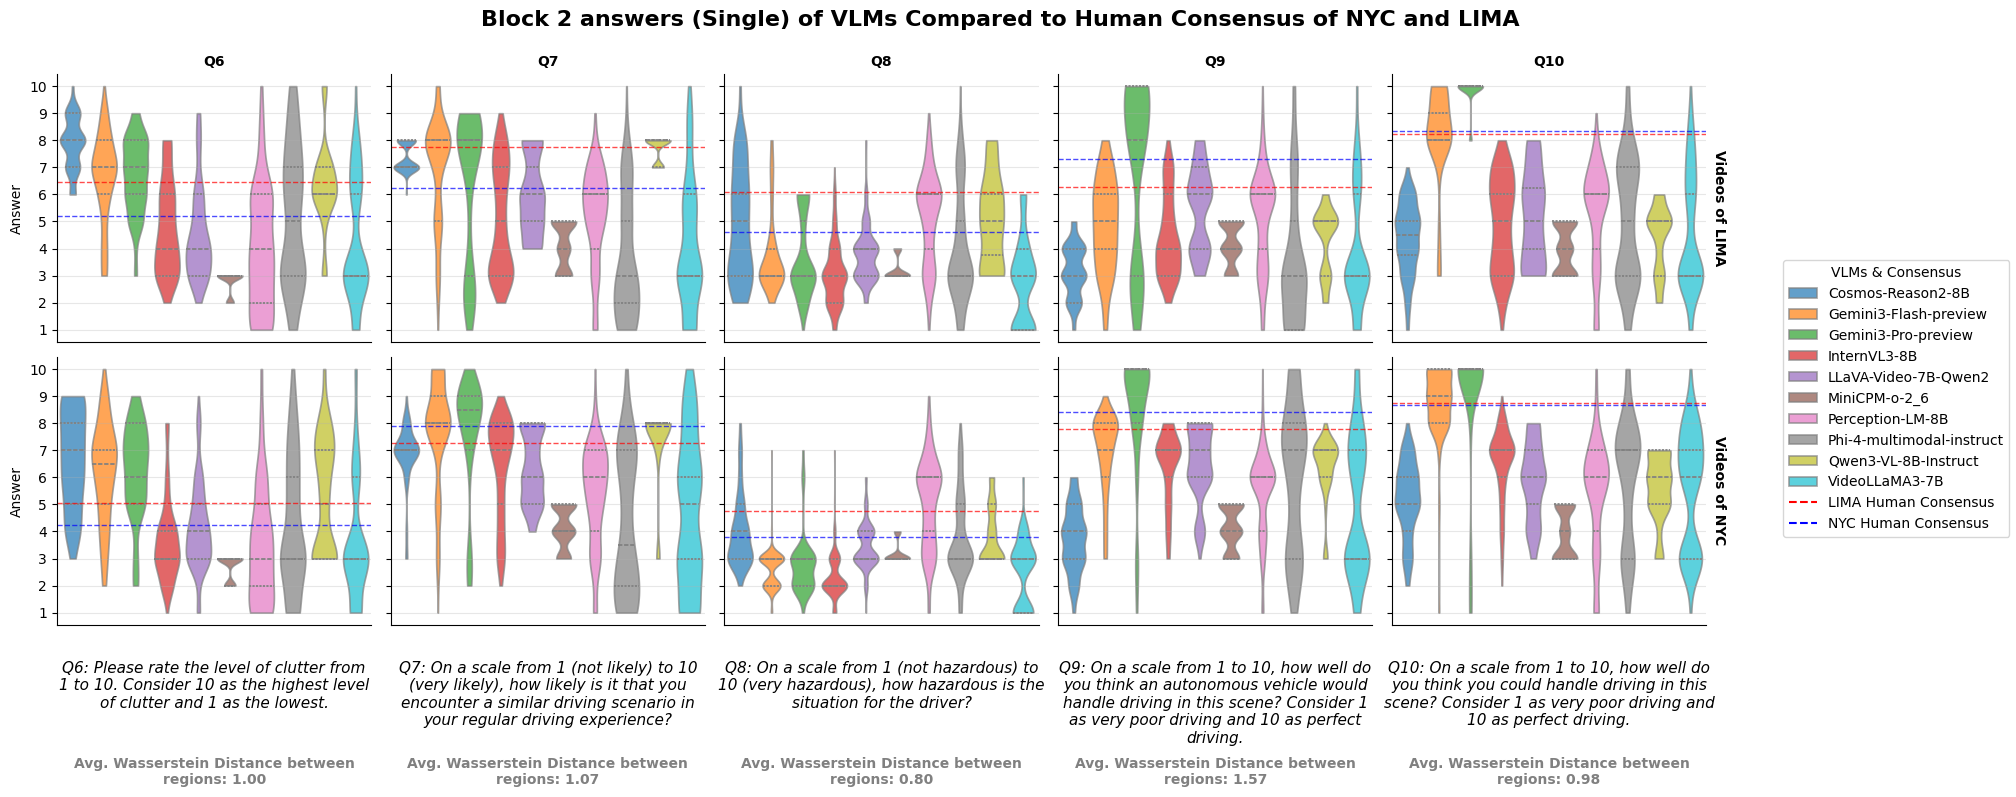

In [16]:
violing_plot_b2(df_vlms_r1, human_consensus, title =  "Block 2 answers (Single) of VLMs Compared to Human Consensus of NYC and LIMA", out_filename = "bias_violin_distribution_clean")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.color_palette("deep")
g = sns.FacetGrid(
    df_vlms,
    row="VIDEO_REGION",
    col="QUESTION_NUM",
    hue="AGENT",
    height=3,
    aspect=1.2,
    margin_titles=True,
    sharey=True,
    sharex=True
)

g.map_dataframe(
    sns.violinplot,
    x="AGENT",
    y="ANSWER",
    inner="quart",
    cut=0,
    dodge=False,
    legend=False,          # evitamos leyenda repetida
    edgecolor="gray",
    saturation=1,
    alpha=0.7
)
for ax in g.axes.flat:
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(bottom=False)
    ax.grid(True, alpha=0.3)
    ax.set_yticks(range(1, 11))  # Fuerza los ticks del 1 al 10



plt.tight_layout()
g.set_titles(row_template="{row_name}", col_template="Q{col_name}", fontweight='bold')
g.set_axis_labels("", "Score")
g.figure.suptitle(
    "Block 2 answers of VLMs Compared to Human Consensus of NYC and LIMA",
    fontsize=16,
    fontweight='bold',
    y=1.05
)

#get the regions array
regs = list(df_vlms["VIDEO_REGION"].unique())
q_nums = list(df_vlms["QUESTION_NUM"].unique())

for i in range(g.axes.shape[0]):      # filas
    for j in range(g.axes.shape[1]):  # columnas
        ax = g.axes[i, j]
        
        region = regs[i]
        question = q_nums[j]
        
        #get avg from human consensus for that region and question
        lima_human_consensus = human_consensus[
            (human_consensus["HUMAN_REGION"] == "LIMA") &
            (human_consensus["QUESTION_NUM"] == question) &
            (human_consensus["VIDEO_REGION"] == region)
        ]["ANSWER"].values 
        
        nyc_human_consensus = human_consensus[
            (human_consensus["HUMAN_REGION"] == "NYC") &
            (human_consensus["QUESTION_NUM"] == question) &
            (human_consensus["VIDEO_REGION"] == region)
        ]["ANSWER"].values
        
        
        ax.axhline(
            lima_human_consensus,
            linestyle="--",
            linewidth=1,
            color="red",
            alpha=0.7
        )
        
        ax.axhline(
            nyc_human_consensus,
            linestyle="--",
            linewidth=1,
            color="blue",
            alpha=0.7
        )
        #print(f"Row {i}, Col {j}")
    
#now make up separation between rows because the lael axis is too large
# Agregar una sola leyenda global
g.add_legend(title="Agents")
#add to the already created legend the red and blue lines for lima and nyc human consensus
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='red', linestyle='--', label='LIMA Human Consensus'),
    Line2D([0], [0], color='blue', linestyle='--', label='NYC Human Consensus')
]

# Obtener handles y labels actuales
handles, labels = g.axes[0,0].get_legend_handles_labels()

# Agregar tus líneas custom
handles += custom_lines
labels += ['LIMA Human Consensus', 'NYC Human Consensus']

# Remover la leyenda anterior
g._legend.remove()

# Crear nueva leyenda combinada
g.figure.legend(
    handles,
    labels,
    loc="center right",
    ncol=1,
    title="VLMs & Consensus",
)

QUESTIONS = {
    6:"Q6: Please rate the level of clutter from 1 to 10. Consider 10 as the highest level of clutter and 1 as the lowest.",
    7:"Q7: On a scale from 1 (not likely) to 10 (very likely), how likely is it that you encounter a similar driving scenario in your regular driving experience?",
    8:"Q8: On a scale from 1 (not hazardous) to 10 (very hazardous), how hazardous is the situation for the driver?",
    9:"Q9: On a scale from 1 to 10, how well do you think an autonomous vehicle would handle driving in this scene? Consider 1 as very poor driving and 10 as perfect driving.",
    10:"Q10: On a scale from 1 to 10, how well do you think you could handle driving in this scene? Consider 1 as very poor driving and 10 as perfect driving.",
}

import textwrap

for j, col_name in enumerate(g.col_names):

    ax = g.axes[-1, j]
    bbox = ax.get_position()

    x_center = (bbox.x0 + bbox.x1) / 2
    col_width = bbox.x1 - bbox.x0

    raw_text = QUESTIONS.get(col_name, "")

    #ADD THE avg wasserstein distance for that question in the text
    avg_wasserstein = wasserteIn_avg[wasserteIn_avg["QUESTION_NUM"] == col_name]["WASSERSTEIN_DISTANCE"].values[0]
    # Ajusta 35 según qué tan ancho sea tu subplot
    wrapped_text = textwrap.fill(raw_text, width=42)

    g.figure.text(
        x_center,
        bbox.y0 - 0.06,
        wrapped_text,
        ha="center",
        va="top",
        fontstyle="italic",
        fontsize=11,
    )
    
    #now put the avg wasserstein distance in the text below the question
    raw_text_2 = f"Avg. Wasserstein Distance between regions: {avg_wasserstein:.2f}"
    wrapped_text_2 = textwrap.fill(raw_text_2, width=40)
    g.figure.text(
        x_center,
        bbox.y0 - 0.22,
        wrapped_text_2,
        ha="center",
        va="top",
        fontsize=10,
        color="gray",
        fontweight="bold"
    )


# add leyend with red and blue lines
plt.savefig("bias_violin_distribution_clean.png", dpi=150, bbox_inches='tight')
plt.savefig("bias_violin_distribution_clean.svg")
plt.show()

In [11]:
from scipy.stats import wasserstein_distance, ks_2samp

df_vlms_mean = df_vlms.groupby(["AGENT","VIDEO", "QUESTION_NUM", "VIDEO_REGION"], as_index=False)["ANSWER"].mean()
df_vlms_mean.sort_values(by=["VIDEO_REGION", "QUESTION_NUM"], inplace=True)

df_video = df_vlms_mean

agents = df_video["AGENT"].unique()
questions = df_video["QUESTION_NUM"].unique()

df_stats = pd.DataFrame(columns=["AGENT", "QUESTION_NUM", "WASSERSTEIN_DISTANCE","KS_2SAMP_STATISTIC", "KS_2SAMP_PVALUE"])

for agent in agents:
    df_agent = df_video[df_video["AGENT"] == agent]
    for question in questions:
        df_values = df_agent[df_agent["QUESTION_NUM"] == question][["VIDEO_REGION", "ANSWER"]]
        #print(f"Agent: {agent} at Question {question}")
        #separate by video region and compute the number of rows for each region
        values = []
        for region in df_values["VIDEO_REGION"].unique():
            region_values = df_values[df_values["VIDEO_REGION"] == region]["ANSWER"]
            values.append(region_values.to_list())
        
        assert len(values) == 2, "There should be exactly two regions"    
        r = wasserstein_distance(values[0], values[1])
        stat,p = ks_2samp(values[0], values[1])
        
        df_stats.loc[len(df_stats)] = {
            "AGENT": agent,
            "QUESTION_NUM": question,
            "WASSERSTEIN_DISTANCE": r,
            "KS_2SAMP_STATISTIC": stat,
            "KS_2SAMP_PVALUE": p
        }      

wasserteIn_avg =  df_stats.groupby("QUESTION_NUM")["WASSERSTEIN_DISTANCE"].mean().reset_index()
wasserteIn_avg

,QUESTION_NUM,WASSERSTEIN_DISTANCE
0,6,0.711187
1,7,0.679795
2,8,0.633500
3,9,1.321500
4,10,0.812974


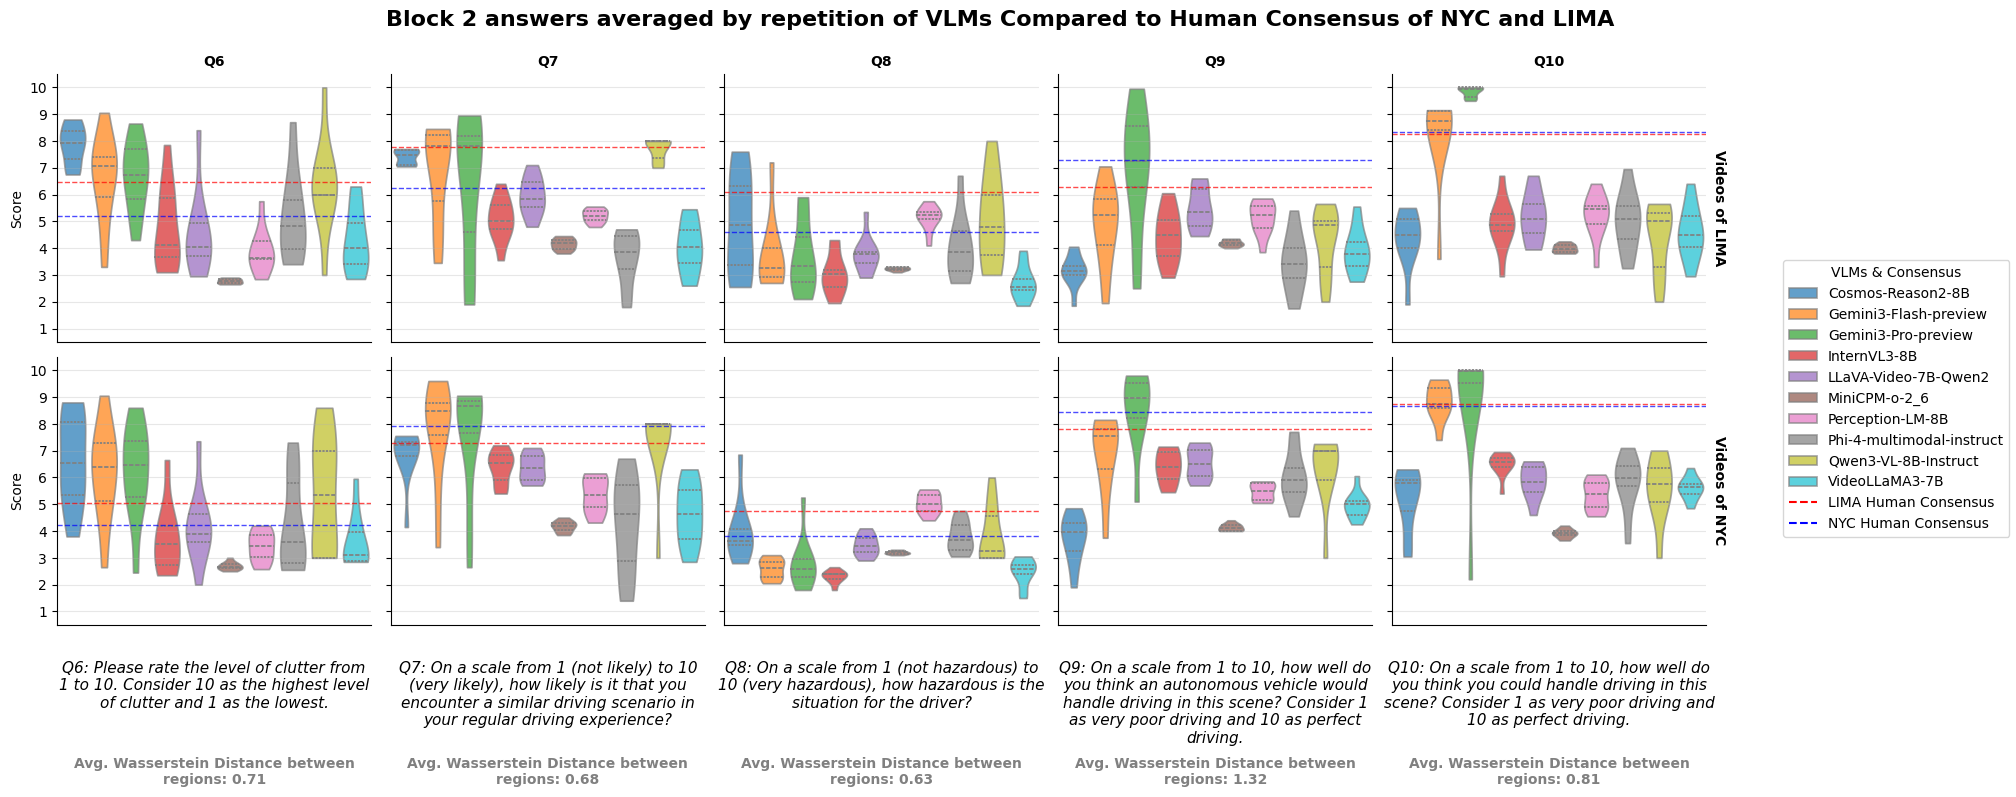

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.color_palette("deep")
g = sns.FacetGrid(
    df_vlms_mean,
    row="VIDEO_REGION",
    col="QUESTION_NUM",
    hue="AGENT",
    height=3,
    aspect=1.2,
    margin_titles=True,
    sharey=True,
    sharex=True
)

g.map_dataframe(
    sns.violinplot,
    x="AGENT",
    y="ANSWER",
    inner="quart",
    cut=0,
    dodge=False,
    legend=False,          # evitamos leyenda repetida
    edgecolor="gray",
    saturation=1,
    alpha=0.7,
)
for ax in g.axes.flat:
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(bottom=False)
    ax.grid(True, alpha=0.3)
    ax.set_yticks(range(1, 11))  # Fuerza los ticks del 1 al 10
    ax.set_ylim(0.5, 10.5)       # Ajusta el límite para que no se corten los extremos
    
    # Opcional: Si quieres que se vea más limpio, añade etiquetas de texto
    # ax.set_yticklabels([str(i) for i in range(1, 11)])


plt.tight_layout()
g.set_titles(row_template="{row_name}", col_template="Q{col_name}", fontweight='bold')
g.set_axis_labels("", "Score")
g.figure.suptitle(
    "Block 2 answers averaged by repetition of VLMs Compared to Human Consensus of NYC and LIMA",
    fontsize=16,
    fontweight='bold',
    y=1.05
)

#get the regions array
regs = list(df_vlms["VIDEO_REGION"].unique())
q_nums = list(df_vlms["QUESTION_NUM"].unique())

for i in range(g.axes.shape[0]):      # filas
    for j in range(g.axes.shape[1]):  # columnas
        ax = g.axes[i, j]
        
        region = regs[i]
        question = q_nums[j]
        
        #get avg from human consensus for that region and question
        lima_human_consensus = human_consensus[
            (human_consensus["HUMAN_REGION"] == "LIMA") &
            (human_consensus["QUESTION_NUM"] == question) &
            (human_consensus["VIDEO_REGION"] == region)
        ]["ANSWER"].values 
        
        nyc_human_consensus = human_consensus[
            (human_consensus_df["HUMAN_REGION"] == "NYC") &
            (human_consensus["QUESTION_NUM"] == question) &
            (human_consensus["VIDEO_REGION"] == region)
        ]["ANSWER"].values
        
        
        ax.axhline(
            lima_human_consensus,
            linestyle="--",
            linewidth=1,
            color="red",
            alpha=0.7
        )
        
        ax.axhline(
            nyc_human_consensus,
            linestyle="--",
            linewidth=1,
            color="blue",
            alpha=0.7
        )
        #print(f"Row {i}, Col {j}")
    
#now make up separation between rows because the lael axis is too large
# Agregar una sola leyenda global
g.add_legend(title="Agents")
#add to the already created legend the red and blue lines for lima and nyc human consensus
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='red', linestyle='--', label='LIMA Human Consensus'),
    Line2D([0], [0], color='blue', linestyle='--', label='NYC Human Consensus')
]

# Obtener handles y labels actuales
handles, labels = g.axes[0,0].get_legend_handles_labels()

# Agregar tus líneas custom
handles += custom_lines
labels += ['LIMA Human Consensus', 'NYC Human Consensus']

# Remover la leyenda anterior
g._legend.remove()

# Crear nueva leyenda combinada
g.figure.legend(
    handles,
    labels,
    loc="center right",
    ncol=1,
    title="VLMs & Consensus",
)

QUESTIONS = {
    6:"Q6: Please rate the level of clutter from 1 to 10. Consider 10 as the highest level of clutter and 1 as the lowest.",
    7:"Q7: On a scale from 1 (not likely) to 10 (very likely), how likely is it that you encounter a similar driving scenario in your regular driving experience?",
    8:"Q8: On a scale from 1 (not hazardous) to 10 (very hazardous), how hazardous is the situation for the driver?",
    9:"Q9: On a scale from 1 to 10, how well do you think an autonomous vehicle would handle driving in this scene? Consider 1 as very poor driving and 10 as perfect driving.",
    10:"Q10: On a scale from 1 to 10, how well do you think you could handle driving in this scene? Consider 1 as very poor driving and 10 as perfect driving.",
}

import textwrap

for j, col_name in enumerate(g.col_names):

    ax = g.axes[-1, j]
    bbox = ax.get_position()

    x_center = (bbox.x0 + bbox.x1) / 2
    col_width = bbox.x1 - bbox.x0

    raw_text = QUESTIONS.get(col_name, "")

    #ADD THE avg wasserstein distance for that question in the text
    avg_wasserstein = wasserteIn_avg[wasserteIn_avg["QUESTION_NUM"] == col_name]["WASSERSTEIN_DISTANCE"].values[0]
    # Ajusta 35 según qué tan ancho sea tu subplot
    wrapped_text = textwrap.fill(raw_text, width=42)

    g.figure.text(
        x_center,
        bbox.y0 - 0.06,
        wrapped_text,
        ha="center",
        va="top",
        fontstyle="italic",
        fontsize=11,
    )
    #now put the avg wasserstein distance in the text below the question
    raw_text_2 = f"Avg. Wasserstein Distance between regions: {avg_wasserstein:.2f}"
    wrapped_text_2 = textwrap.fill(raw_text_2, width=40)
    g.figure.text(
        x_center,
        bbox.y0 - 0.22,
        wrapped_text_2,
        ha="center",
        va="top",
        fontsize=10,
        color="gray",
        fontweight="bold"
    )
    


# add leyend with red and blue lines
plt.savefig("bias_violin_distribution_clean_mean.png", dpi=150, bbox_inches='tight')
plt.savefig("bias_violin_distribution_clean_mean.svg")
plt.show()